# Homework 5: Time Series & Gridded Climate Data
## F&W ECOL 458: Environmental Data Science
### Covers Lectures 10 & 11

## [Ines Lopez-Silvero]

**Instructions:**
- Complete all code cells marked with `# YOUR CODE HERE`
- Answer all written-response questions in the provided markdown cells
- Run all cells to make sure your code works before submitting
- Push the completed `.ipynb` file to your homework github repo
- Submit the link to the completed `.ipynb` file in your homework github repo to canvas

---

## Setup

In [1]:
# Run this cell first — installs and imports
!pip install xarray netCDF4 statsmodels cartopy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.9 MB/s eta 0:00:00


In [5]:
# Mount Google Drive (the NetCDF file is stored there)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

---
## Problem 1: Time Series Analysis of Simulated Weather Data (50 pts)

In this problem you will practice the core time-series skills from Lecture 10: resampling, rolling averages, and seasonal decomposition. We'll use a synthetic daily weather dataset for Madison, WI that has realistic seasonal patterns.

Run the cell below to generate the data — **do not modify it.**

In [4]:
# === DO NOT MODIFY THIS CELL — it creates the dataset ===
import numpy as np
import pandas as pd
np.random.seed(458)

dates = pd.date_range('2018-01-01', '2024-12-31', freq='D')
n = len(dates)
doy = dates.dayofyear

# Seasonal cycle + slight warming trend + noise
seasonal = 16 * np.sin(2 * np.pi * (doy - 80) / 365)
trend = np.linspace(0, 1.5, n)
noise = np.random.normal(0, 4, n)
temperature = 8 + seasonal + trend + noise  # °C

# Precipitation (exponential with seasonal modulation)
precip_rate = 2.5 + 1.0 * np.sin(2 * np.pi * (doy - 120) / 365)
precipitation = np.random.exponential(precip_rate)  # mm

weather = pd.DataFrame({
    'date': dates,
    'temperature_c': temperature,
    'precipitation_mm': precipitation
})

# Set date as index (DatetimeIndex)
weather = weather.set_index('date')

print(f"Dataset: {len(weather)} days, {weather.index[0].date()} to {weather.index[-1].date()}")
weather.head()

Dataset: 2557 days, 2018-01-01 to 2024-12-31


,temperature_c,precipitation_mm
date,,
2018-01-01,-9.181843,0.431327
2018-01-02,-9.816574,3.576616
2018-01-03,-9.838835,3.675735
2018-01-04,-1.018871,1.621691
2018-01-05,-0.786900,1.075056


### Part A — Resampling (15 pts)

**A1 (5 pts).** Resample the daily temperature data to **monthly means**. Store the result in a variable called `monthly_temp`. Print the first 12 values.

In [6]:
# YOUR CODE HERE
monthly_temp=weather['temperature_c'].resample('M').mean()
monthly_temp.head(12)

/tmp/ipykernel_986/1498721802.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp=weather['temperature_c'].resample('M').mean()


,temperature_c
date,
2018-01-31,-5.912906
2018-02-28,-1.930791
2018-03-31,5.660184
2018-04-30,15.965819
2018-05-31,19.914196
2018-06-30,23.437270
2018-07-31,22.150953
2018-08-31,16.451168
2018-09-30,9.757707


**A2 (5 pts).** Resample the daily precipitation data to **annual totals** (sum). Store the result in a variable called `annual_precip`. Print all values.

In [7]:
# YOUR CODE HERE
annual_precip=weather['precipitation_mm'].resample('M').sum()
annual_precip.head(12)

/tmp/ipykernel_986/3503703503.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  annual_precip=weather['precipitation_mm'].resample('M').sum()


,precipitation_mm
date,
2018-01-31,44.468592
2018-02-28,52.575694
2018-03-31,53.522473
2018-04-30,60.683339
2018-05-31,88.992651
2018-06-30,133.405703
2018-07-31,129.012647
2018-08-31,92.357833
2018-09-30,68.303758


**A3 (5 pts).** Make a bar plot of `annual_precip` with year on the x-axis and total precipitation (mm) on the y-axis. Add axis labels and a title.

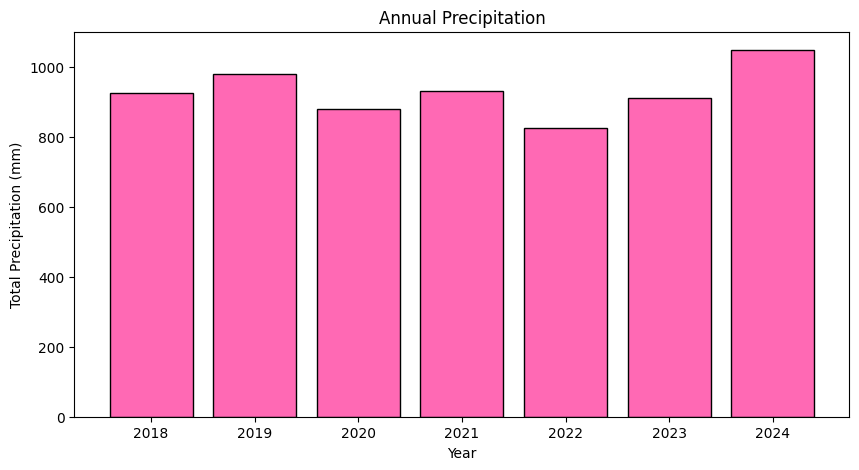

In [16]:
import matplotlib.pyplot as plt

# YOUR CODE HERE
annual_precip=weather['precipitation_mm'].resample('YE').sum()
annual_precip.index=annual_precip.index.year

fig, ax=plt.subplots(figsize=(10,5))
ax.bar(annual_precip.index, annual_precip.values,color='hotpink',edgecolor='black')
ax.set_xlabel('Year')
ax.set_ylabel('Total Precipitation (mm)')
ax.set_title('Annual Precipitation')
plt.show()

### Part B — Rolling Averages (15 pts)

**B1 (5 pts).** Calculate a **30-day rolling mean** of temperature. Store it in a new column called `temp_30day_ma`.

In [12]:
# YOUR CODE HERE
temp_30day_ma=weather['temperature_c'].rolling(window=30).mean()
weather[['temperature_c','temp_30day_ma']].head(10)

,temperature_c,temp_30day_ma
date,,
2018-01-01,-9.181843,NaN
2018-01-02,-9.816574,NaN
2018-01-03,-9.838835,NaN
2018-01-04,-1.018871,NaN
2018-01-05,-0.786900,NaN
2018-01-06,-9.409719,NaN
2018-01-07,-6.396947,NaN
2018-01-08,-1.783123,NaN
2018-01-09,-6.058594,NaN


**B2 (10 pts).** Create a figure that shows **one year of data (2023)** with:
- The raw daily temperature as a thin, semi-transparent line
- The 30-day rolling mean as a thicker line on top
- A legend, axis labels, and a title

*Hint:* Use `.loc['2023']` to select the year.

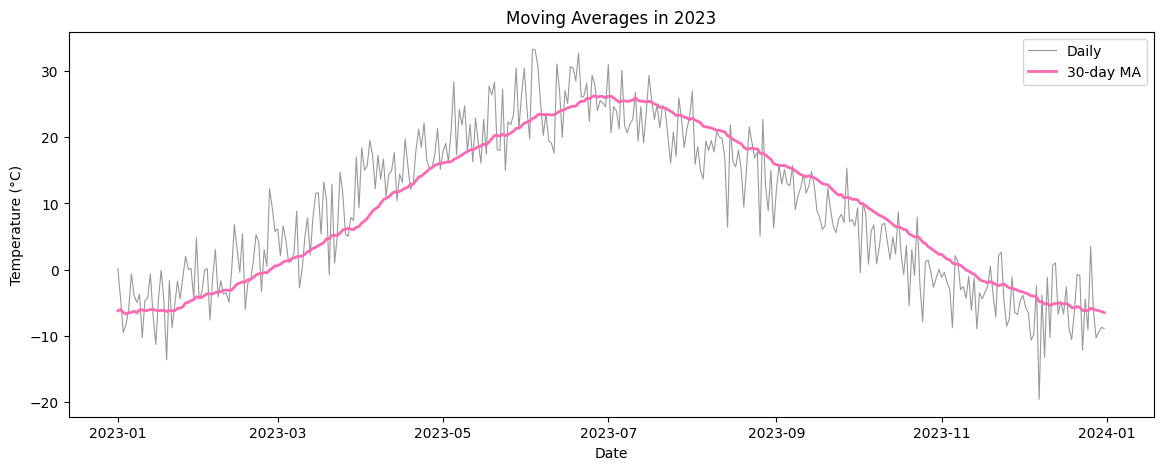

In [13]:
# YOUR CODE HERE
fig,ax=plt.subplots(figsize=(14,5))
year_data=weather.loc['2023']

ax.plot(year_data.index, year_data['temperature_c'],
        alpha=0.4, linewidth=0.8, label='Daily',color='black')
ax.plot(year_data.index, year_data['temp_30day_ma'],
        linewidth=2, label='30-day MA', color='hotpink')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Moving Averages in 2023')
ax.legend()
plt.show()

### Part C — Seasonal Decomposition (20 pts)

**C1 (5 pts).** Use `seasonal_decompose()` from statsmodels to decompose `monthly_temp` (the monthly means you created in Part A). Use `period=12` for an annual cycle. Store the result in a variable called `decomp`.

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import axes
# YOUR CODE HERE
decomposition=seasonal_decompose(
    monthly_temp,
    model='additive',
    period=12
)


**C2 (5 pts).** Plot the four decomposition panels (observed, trend, seasonal, residual) using `decomp.plot()`. Set the figure size to (14, 10).

Componenents:
 - Trend: <class 'pandas.core.series.Series'>
 - Seasonal: <class 'pandas.core.series.Series'>
 - Residual: <class 'pandas.core.series.Series'>


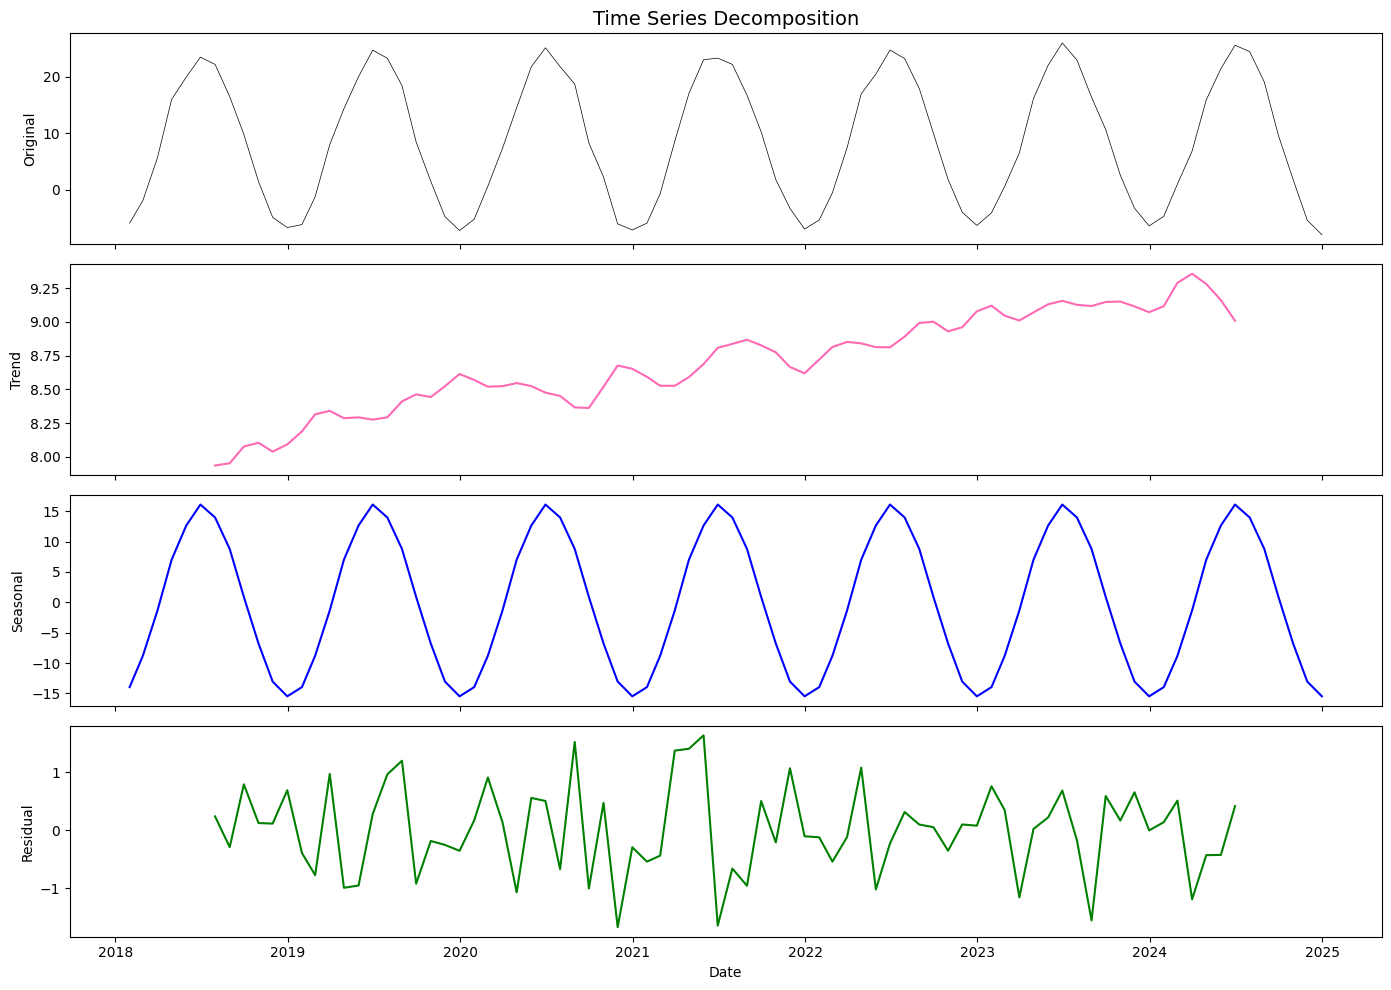

In [22]:
# YOUR CODE HERE
decomposition=seasonal_decompose(
    monthly_temp,
    model='additive',
    period=12
)
print("Componenents:")
print(f" - Trend: {type(decomposition.trend)}")
print(f" - Seasonal: {type(decomposition.seasonal)}")
print(f" - Residual: {type(decomposition.resid)}")

fig, axes=plt.subplots(4,1,figsize=(14,10),sharex=True)
axes[0].plot(monthly_temp.index, monthly_temp, linewidth=0.5,color='black') # Plot monthly_temp as original
axes[0].set_ylabel('Original')
axes[0].set_title('Time Series Decomposition', fontsize=14)

axes[1].plot(decomposition.trend.index, decomposition.trend, color='hotpink',linewidth=1.5)
axes[1].set_ylabel('Trend')

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='blue',linewidth=1.5)
axes[2].set_ylabel('Seasonal')

axes[3].plot(decomposition.resid.index, decomposition.resid, color='green',linewidth=1.5)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

**C3 (10 pts).** Answer the following questions in 1–2 sentences each.

1. Looking at the **trend** component: does temperature appear to be increasing, decreasing, or staying the same over the 7-year record?
2. Looking at the **seasonal** component: approximately what is the range (warmest minus coldest) of the annual temperature cycle in °C?
3. Why did we use `period=12` instead of `period=365` here?

*Your answers:*

1. Based off the trend component, temperature is increasing. We can observe an upward slope beginning roughly at 8 in 2018 to about 9.25 in 2024.
2. Looking at the seasonal component the range of the annual temperature cycle is about 30 C. The warmest it gets is 15C and the lowest it gets is -15C. 15 - (-15)=30.
3. We use period=12 insetad of period=365 because we are looking at monthly temperature data not daily.


---
## Problem 2: Gridded Climate Data with xarray (50 pts)

In this problem you will work with the real **CRU TS4.09 temperature dataset** (CONUS subset) from Lecture 11. You'll practice selecting data by coordinates and time, computing climate anomalies, and drawing a map.

Run the cell below to load the data — **do not modify it.**

In [7]:
import pandas as pd
import xarray as xr
# === DO NOT MODIFY THIS CELL — it loads the CRU dataset ===
cru_path = '/content/drive/MyDrive/cru_ts4.09.1901.2024.tmp.conus.nc'
ds = xr.open_dataset(cru_path)

print(f"Loaded CRU TS4.09 CONUS temperature dataset")
print(f"  Time: {pd.to_datetime(ds.time.values[0]).date()} to {pd.to_datetime(ds.time.values[-1]).date()}")
print(f"  Lat:  {float(ds.lat.min()):.2f}°N to {float(ds.lat.max()):.2f}°N")
print(f"  Lon:  {float(ds.lon.min()):.2f}° to {float(ds.lon.max()):.2f}°")
print(f"  Shape (time, lat, lon): {ds['tmp'].shape}")
ds

Loaded CRU TS4.09 CONUS temperature dataset
  Time: 1901-01-16 to 2024-12-16
  Lat:  24.75°N to 49.25°N
  Lon:  -124.75° to -66.75°
  Shape (time, lat, lon): (1488, 50, 117)


<xarray.Dataset> Size: 174MB
Dimensions:  (time: 1488, lat: 50, lon: 117)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
  * lat      (lat) float32 200B 24.75 25.25 25.75 26.25 ... 48.25 48.75 49.25
  * lon      (lon) float32 468B -124.8 -124.2 -123.8 ... -67.75 -67.25 -66.75
Data variables:
    tmp      (time, lat, lon) float32 35MB ...
    stn      (time, lat, lon) float64 70MB ...
    mae      (time, lat, lon) float32 35MB ...
    maea     (time, lat, lon) float32 35MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.09 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2503051245. Data generated from:tmp.2503051121.dtb
    history:      CONUS subset (-125.0,24.5)-(-66.5,49.5) extracted from cru_...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

### Part A — Selecting Data (15 pts)

**A1 (5 pts).** Extract the temperature time series for a grid cell near **Denver, CO** (latitude ≈ 39.7°N, longitude ≈ −105.0°). Use `method='nearest'` in `.sel()`. Store the result in a variable called `denver_temp`. Print the shape and the coordinates of the nearest grid point.

In [9]:
# YOUR CODE HERE
denver_lat=39.7
denver_lon=-105.0 # The dataset uses -180 to 180 longitude convention
denver_temp=ds['tmp'].sel(lat=denver_lat, lon=denver_lon, method='nearest')
print(f"Temperature time series at Denver, CO:")
print(f" Nearest grid point: {float(denver_temp.lat):.2f}°N, {float(denver_temp.lon):.2f}°E")
print(f"  Shape: {denver_temp.shape} (one value per month)")
print(f" First 12 values: {denver_temp.values[:12].round(1)}")

Temperature time series at Denver, CO:
 Nearest grid point: 39.75°N, -104.75°E
  Shape: (1488,) (one value per month)
 First 12 values: [-0.4 -4.8  2.   7.6 14.2 18.  23.6 21.3 15.2 10.4  5.4 -1. ]


**A2 (5 pts).** Select all temperature data for the month of **January 2010**. Store it in a variable called `jan_2010`. Print its shape.

In [11]:
# YOUR CODE HERE
jan_2010=ds['tmp'].sel(time='2010-01')
print(f"Temperature time series for January 2010:")
print(f"  Shape: {jan_2010.shape}")


Temperature time series for January 2010:
  Shape: (1, 50, 117)


**A3 (5 pts).** Extract a regional subset covering the **Southeast US**: latitude 25°N to 37°N, longitude −92° to −75°. Store it in a variable called `southeast`. Print the number of latitude and longitude grid cells.

In [13]:
# YOUR CODE HERE
# Correct longitude range for Southeast US in -180 to 180 convention
co_lon_min = -92
co_lon_max = -75

# Correct latitude range for Southeast US
lat_min = 25
lat_max = 37

southeast = ds['tmp'].sel(
    lat=slice(lat_min, lat_max),
    lon=slice(co_lon_min, co_lon_max)
)
print(f"Temperature time series for the Southeast US:")
print(f"Latitude range: {float(southeast.lat.min()):.1f}° to {float(southeast.lat.max()):.1f}°")
print(f"Longitude range: {float(southeast.lon.min()):.1f}° to {float(southeast.lon.max()):.1f}°")
print(f"Grid cells: {southeast.shape[1]} lat x {southeast.shape[2]} lon")
print(f"  Shape: {southeast.shape}")

Temperature time series for the Southeast US:
Latitude range: 25.2° to 36.8°
Longitude range: -91.8° to -75.2°
Grid cells: 24 lat x 34 lon
  Shape: (1488, 24, 34)


### Part B — Climate Anomalies (20 pts)

**B1 (5 pts).** Calculate the **1991–2020 monthly climatology** (i.e., the average January, average February, … average December over that 30-year baseline). Store the result in a variable called `climatology`.

*Hint:* First select the baseline period with `.sel(time=slice(...))`, then use `.groupby('time.month').mean(dim='time')`.

In [16]:
# YOUR CODE HERE
baseline=ds['tmp'].sel(time=slice('1991-01','2020-12'))
climatology=baseline.groupby('time.month').mean(dim='time')
print(f"Climatology Shape: {climatology.shape}")



Climatology Shape: (12, 50, 117)


**B2 (5 pts).** Compute the temperature **anomaly** for the full record by subtracting the climatology from each month. Store the result in a variable called `anomaly`.

*Hint:* `anomaly = ds['tmp'].groupby('time.month') - climatology`

In [17]:
# YOUR CODE HERE
anomaly=ds['tmp'].groupby('time.month')-climatology
print(f"Anomaly shape:{anomaly.shape}")
print(f"Anomaly range:{float(anomaly.min()):.1f}°C to {float(anomaly.max()):.1f}°C")


Anomaly shape:(1488, 50, 117)
Anomaly range:-17.2°C to 9.4°C


**B3 (10 pts).** Using the Denver grid cell from Part A, plot the **monthly anomaly time series** at that location. Your plot should include:
- The anomaly values as a line plot
- A horizontal dashed line at y = 0
- Axis labels and a title that mentions the baseline period

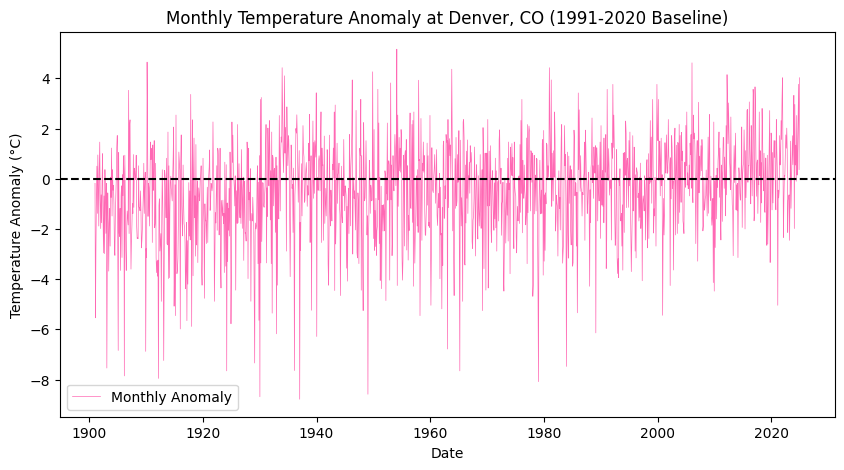

In [20]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

# Extract the anomaly time series for the Denver grid cell
denver_anomaly = anomaly.sel(lat=denver_temp.lat, lon=denver_temp.lon, method='nearest')

plt.figure(figsize=(10,5))
plt.plot(denver_anomaly.time, denver_anomaly, color='hotpink', linewidth=0.5, label="Monthly Anomaly")
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Monthly Temperature Anomaly at Denver, CO (1991-2020 Baseline)')
plt.legend()
plt.show()

### Part C — Drawing a Map (15 pts)

**C1 (15 pts).** Create a map of the **Summer 2012 (June–August) CONUS temperature anomaly** using cartopy. Summer 2012 was one of the hottest summers on record for the US, so this is a great case to visualize.

Your map should include:
- A **diverging colormap** centered at 0 (e.g., `cmap='RdBu_r', center=0`)
- **State boundaries** (`cfeature.STATES`)
- **Coastlines**
- A **colorbar** with a label
- A **title**

You may use either Plate Carrée or Lambert Conformal Conic projection.

*Hint:* First compute the summer 2012 mean anomaly with:
```python
summer_2012 = anomaly.sel(time=slice('2012-06', '2012-08')).mean(dim='time')
```
Then follow the cartopy recipe from Lecture 11.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


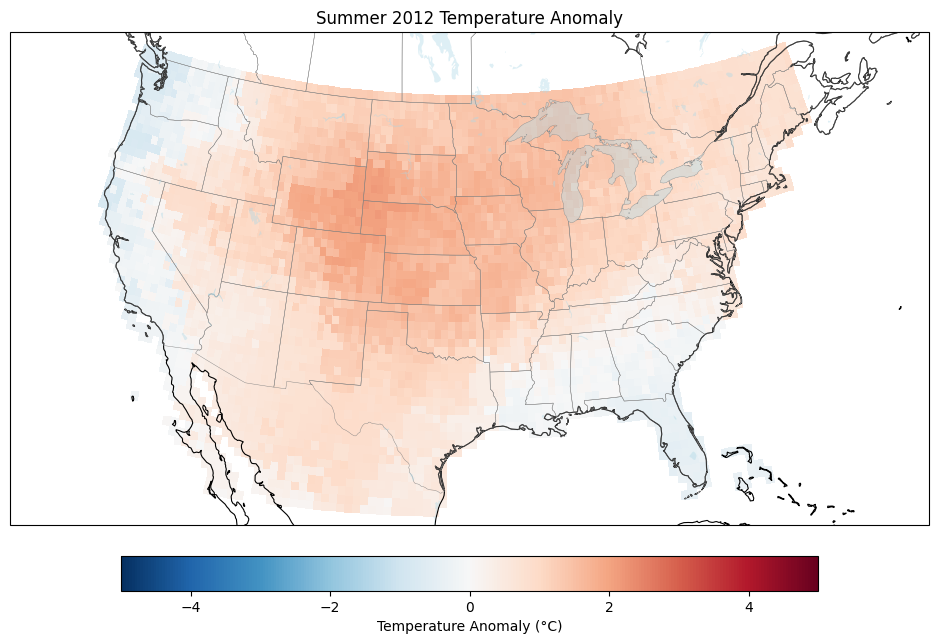

In [28]:
!pip install cartopy -q
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# YOUR CODE HERE
summer_2012=anomaly.sel(time=slice("2012-06","2012-08")).mean(dim='time')
projection=ccrs.LambertConformal(
    central_longitude=-96, central_latitude=30, standard_parallels=(33,45)
)
fig, ax=plt.subplots(figsize=(15,8), subplot_kw={"projection": projection})
ax.set_extent([-125,-66,24,50], crs=ccrs.PlateCarree())

summer_2012.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    center=0,
    vmin=-5, vmax=5,
    cbar_kwargs={"label": "Temperature Anomaly (°C)", "shrink":0.6,
                 "orientation":"horizontal","pad":0.05}
)
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor="gray")
ax.add_feature(cfeature.LAKES, alpha=0.4, facecolor="lightblue")
ax.set_title("Summer 2012 Temperature Anomaly")
plt.show()